#### Реальный кейс: Мониторинг температуры и вибрации подшипника

Напишем код, который симулирует работу датчиков станка и находит момент,  
когда подшипник начинает разрушаться. Использовать будем самый эффективный  
алгоритм — Isolation Forest.


Шаг 1: Симулируем нормальную работу и зарождение поломки


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest

# Генерируем 1000 временных меток (например, показания раз в 1 час)
np.random.seed(42)
n_readings = 1000

# Симулируем нормальную работу станка (небольшие случайные колебания)
vibration = np.random.normal(loc=2.0, scale=0.2, size=n_readings)  # Вибрация вокруг 2.0 мм/с
temperature = np.random.normal(loc=65.0, scale=1.5, size=n_readings)  # Температура вокруг 65°C

# Симулируем аномалию (последние 40 часов подшипник начинает греться и вибрировать перед поломкой)
vibration[-40:] = vibration[-40:] + np.random.uniform(1.0, 2.5, size=40)
temperature[-40:] = temperature[-40:] + np.random.uniform(10.0, 25.0, size=40)

df_machinery = pd.DataFrame({"Vibration": vibration, "Temperature": temperature})

df_machinery.head()


,Vibration,Temperature
0,2.099343,67.099033
1,1.972347,66.386951
2,2.129538,65.089446
3,2.304606,64.029595
4,1.953169,66.047335


Шаг 2: Обучаем IsolationForest

Главный параметр здесь — contamination (уровень загрязнения). Это процент аномалий,  
который мы ожидаем увидеть в данных. На производстве это обычно доли процента  
(например, 0.01), но для нашего теста поставим 0.05 (5%).


In [4]:
# Инициализируем модель
# В отличие от обучения с учителем, мы не делим данные на X_train и y_train!
model_if = IsolationForest(contamination=0.05, random_state=42)

# Обучаем модель на всем массиве данных и сразу получаем предсказания
# Модель вернет: 1 для нормы, -1 для аномалии
df_machinery["Anomaly_Score"] = model_if.fit_predict(df_machinery[["Vibration", "Temperature"]])

# Посмотрим, сколько аномалий нашел алгоритм
print(df_machinery["Anomaly_Score"].value_counts())

Anomaly_Score
 1    950
-1     50
Name: count, dtype: int64


Шаг 3: Визуализация — ловим поломку на графике

Построим график изменения температуры и подсветим красными точками места, где алгоритм Isolation Forest заподозрил неладное.


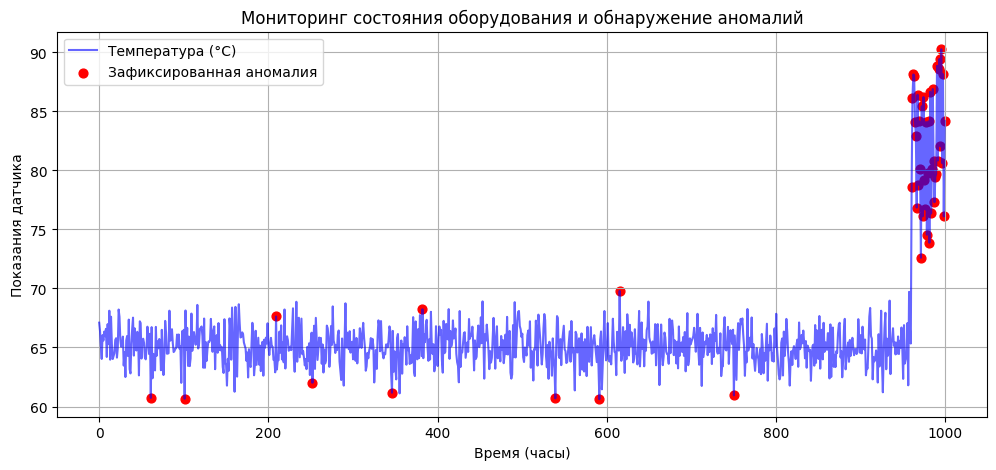

In [5]:
plt.figure(figsize=(12, 5))

# Строим линию температуры
plt.plot(
    df_machinery.index,
    df_machinery["Temperature"],
    color="blue",
    label="Температура (°C)",
    alpha=0.6,
)

# Накладываем красные точки поверх линии в местах аномалий
anomalies = df_machinery[df_machinery["Anomaly_Score"] == -1]
plt.scatter(
    anomalies.index, anomalies["Temperature"], color="red", label="Зафиксированная аномалия", s=40
)

plt.xlabel("Время (часы)")
plt.ylabel("Показания датчика")
plt.title("Мониторинг состояния оборудования и обнаружение аномалий")
plt.legend()
plt.grid(True)
plt.show()

Как алгоритм отличает случайный единичный «чих» оборудования (например, упавший гаечный ключ) от реальной зарождающейся поломки?

Шаг 4: Симулируем случайный «шум» (удар ключа)

Возьмем наш код из предыдущего шага и добавим в него одиночный мощный выброс в самом начале, когда оборудование работает абсолютно исправно.


In [ ]:
df_noisy = df_machinery.copy()

# На 200-м часу произошел случайный единичный удар (вибрация взлетела но сразу вернулась в норму)
df_noisy.loc[200, "Vibration"] = 6.5  # !
df_noisy.loc[200, "Temperature"] = 66.0

Если мы сейчас просто прогоним через это IsolationForest, он гарантированно отметит 200-й час как аномалию (-1).  
С точки зрения геометрии, эта точка висит далеко от общего облака, и алгоритм прав. Но для завода это ложная тревога.


Шаг 5: Скользящее окно (Moving Window)

Также есть решения:

- Накопительная сумма (CUSUM)
- Двухуровневые пороги в Isolation Forest

Чтобы отсечь случайные одиночные всплески, инженеры данных никогда не отправляют в модель «сырые» секундные или  
часовые показания. Данные сначала сглаживают с помощью скользящего среднего или оценивают количество аномалий за  
интервал времени. Мы применим стратегию «X аномалий за последние Y часов».


In [7]:
# 1. Переобучаем модель на зашумленных данных
model_if_noisy = IsolationForest(contamination=0.05, random_state=42)
df_noisy["Raw_Anomaly"] = model_if_noisy.fit_predict(df_noisy[["Vibration", "Temperature"]])

# Переводим метки в более удобный формат: 1 — аномалия, 0 — норма
df_noisy["Is_Anomaly"] = (df_noisy["Raw_Anomaly"] == -1).astype(int)

# 2. Применяем скользящее окно (например, за последние 5 часов)
# Считаем, сколько раз алгоритм заподозрил аномалию за этот промежуток
window_size = 5
df_noisy["Anomaly_Density"] = df_noisy["Is_Anomaly"].rolling(window=window_size).sum()

# 3. Финальное бизнес-правило: включаем сирену, только если аномалии идут кучно
# Например, если из последних 5 часов система ругалась минимум 3 раза
df_noisy["FINAL_ALARM"] = df_noisy["Anomaly_Density"] >= 3

# Проверяем точку случайного удара
print("Данные на 200-м часу (удар ключа):")
print(df_noisy.loc[200, ["Vibration", "Raw_Anomaly", "FINAL_ALARM"]])

# Проверяем точку реальной поломки в конце
print("\nДанные на 980-м часу (разрушение подшипника):")
print(df_noisy.loc[980, ["Vibration", "Raw_Anomaly", "FINAL_ALARM"]])

Данные на 200-м часу (удар ключа):
Vibration        6.5
Raw_Anomaly       -1
FINAL_ALARM    False
Name: 200, dtype: object

Данные на 980-м часу (разрушение подшипника):
Vibration      4.362384
Raw_Anomaly          -1
FINAL_ALARM        True
Name: 980, dtype: object


## Решение через нейросеть

#### Топ-3 алгоритма для этой задачи

1. **Autoencoder (Автоэквилибриум / Автокодировщик)** — _Идеально для старта_.
   - **Как работает:** Сеть сжимает данные от датчиков в маленькую "шпаргалку", а затем пытается восстановить  
     их обратно. Мы обучаем её **только на здоровых данных**.
   - **Поиск аномалий:** Когда на вход поступает поломка, сеть не может её правильно восстановить. Разница между  
     входом и выходом (ошибка восстановления) резко растет — это и есть аномалия.

2. **LSTM Autoencoder (или GRU)**
   - **Как работает:** То же самое, что и обычный автокодировщик, но внутри используются рекуррентные слои (LSTM).
   - **Зачем нужен:** Если ваши аномалии зависят от времени (например, плавающий тренд температуры в течение 5 часов,  
     а не резкий скачок).
3. **1D-CNN (Одномерные сверточные сети)**
   - **Как работает:** Сеть сканирует сигналы датчиков (как картинку) в поисках аномальных паттернов или частот  
     (например, специфический стук или вибрация подшипника).


### Реализация Автоэнкодера на Python (PyTorch)


🔥 Главные методы масштабирования для нейросетей (критично на 100%)

1. `StandardScaler` — Король для скрытых слоев с ReLU / GELU (По умолчанию)

2. `MinMaxScaler` — Выбор для Sigmoid / Tanh и Автокодировщиков
   - **С активацией Sigmoid**: На входе или на выходе. Сигмоида «живет» в диапазоне (0, 1).
   - **С активацией Tanh**: `MinMaxScaler(feature_range=(-1, 1))`. Это стандарт для **LSTM** и **RNN** сетей при работе со временем и текстом.


### Как работает Autoencoder (Автоэнкодер) в поиске аномалий?

В отличие от `IsolationForest`, который ищет точки на "окраинах" пространства, автоэнкодер работает по принципу **сжатия и восстановления**:

1. **Encoder** сжимает входные данные (в нашем случае 2 признака: вибрация и температура) в скрытое представление меньшей размерности (Bottleneck).
2. **Decoder** пытается разжать это обратно в исходные 2 признака.

**Главный трюк:** Мы обучаем сеть **только на нормальных данных** (или на данных, где аномалий минимум). Сеть учится идеально восстанавливать нормальную работу станка. Когда на вход поступает аномалия (перегрев подшипника), сеть пропускает её через "бутылочное горлышко", но так как она никогда не видела таких паттернов, **она не сможет её правильно восстановить**.

Разница между входом и выходом называется **Reconstruction Error (MSE Loss)**. Если эта ошибка превышает порог — мы объявляем тревогу.

### Важное отличие нейросетей от деревьев (Isolation Forest)

Деревьям (и лесам) плевать на масштаб данных. Вибрация равна `2.0`, а температура `65.0` — для IF это просто числа. Нейросети используют градиентный спуск. Если один признак измеряется десятками, а другой единицами, градиенты "перекосит", и сеть будет обращать внимание только на температуру. **Данные обязательно нужно нормализовать!**


In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler

# 1. Подготовка данных
# Приводим признаки к одному масштабу
scaler = StandardScaler()

# В идеале обучаем scaler только на нормальных данных
# чтобы аномалоии не сместили среднее
train_data = df_noisy.loc[:500, ["Vibration", "Temperature"]].values
scaler.fit(train_data)

# Нормализуем весь датасет
X_scaled = scaler.transform(df_noisy[["Vibration", "Temperature"]].values)

# Переводим в тензоры PyTorch
X_tensor = torch.FloatTensor(X_scaled)


# 2. Архитектура Автоэнкодера
class AnomalyAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        # Сжимаем: 2 признака -> 16 нейронов -> 1 нейрон (Bottleneck)
        self.encoder = nn.Sequential(nn.Linear(2, 16), nn.ReLU(), nn.Linear(16, 1))
        # Восстанавливаем: 1 нейрон -> 16 нейронов -> 2 признака
        self.decoder = nn.Sequential(nn.Linear(1, 16), nn.ReLU(), nn.Linear(16, 2))

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded


# init модель, функцию потерь и оптимизатор
model_ae = AnomalyAutoencoder()
criterion = nn.MSELoss()
optimizer = optim.Adam(model_ae.parameters(), lr=0.01)

# 3. Обучение (только на нормальных данных!)
X_train_tensor = torch.FloatTensor(scaler.transform(train_data))
# !!!

epochs = 150
model_ae.train()
for epoch in range(epochs):
    optimizer.zero_grad()
    # Прогоняем данные
    reconstructed = model_ae(X_train_tensor)
    # Считаем ошибку между входом и выходом
    loss = criterion(reconstructed, X_train_tensor)
    # Обратное распространение ошибки
    loss.backward()
    optimizer.step()

print(f"Обучение завершено. Финальный Loss на нормальных данных: {loss.item():.4f}")

# 4. Инференс (поиск аномалий на всем датасете)
model_ae.eval()
with torch.no_grad():
    predictions = model_ae(X_tensor)
    # Считаем MSE для каждой строки отдельно (по оси 1)
    mse_per_row = torch.mean((X_tensor - predictions) ** 2, dim=1).numpy()

df_noisy["AE_Reconstruction_Error"] = mse_per_row

# 5. Устанавливаем порог
# Например, 99-й перцентиль ошибки на нормальных (обучающих) данных
threshold = np.percentile(df_noisy.loc[:500, "AE_Reconstruction_Error"], 99)

# Все, что выше порога - аномалия
df_noisy["AE_Is_Anomaly"] = (df_noisy["AE_Reconstruction_Error"] > threshold).astype(int)

# 6. Применяем ТВОЕ бизнес-правило (скользящее окно)
df_noisy["AE_Anomaly_Density"] = df_noisy["AE_Is_Anomaly"].rolling(window=5).sum()
df_noisy["AE_FINAL_ALARM"] = df_noisy["AE_Anomaly_Density"] >= 3

# --- Проверяем результаты ---
print(f"\nПорог ошибки MSE: {threshold:.4f}")

print("\nДанные на 200-м часу (удар ключа - должен быть проигнорирован финальным алармом):")
print(
    df_noisy.loc[200, ["Vibration", "AE_Reconstruction_Error", "AE_Is_Anomaly", "AE_FINAL_ALARM"]]
)

print("\nДанные на 980-м часу (разрушение подшипника - должен быть FINAL ALARM):")
print(
    df_noisy.loc[980, ["Vibration", "AE_Reconstruction_Error", "AE_Is_Anomaly", "AE_FINAL_ALARM"]]
)


Обучение завершено. Финальный Loss на нормальных данных: 0.2177

Порог ошибки MSE: 1.4226

Данные на 200-м часу (удар ключа - должен быть проигнорирован финальным алармом):
Vibration                       6.5
AE_Reconstruction_Error    0.000369
AE_Is_Anomaly                     0
AE_FINAL_ALARM                False
Name: 200, dtype: object

Данные на 980-м часу (разрушение подшипника - должен быть FINAL ALARM):
Vibration                    4.362384
AE_Reconstruction_Error    190.111557
AE_Is_Anomaly                       1
AE_FINAL_ALARM                   True
Name: 980, dtype: object


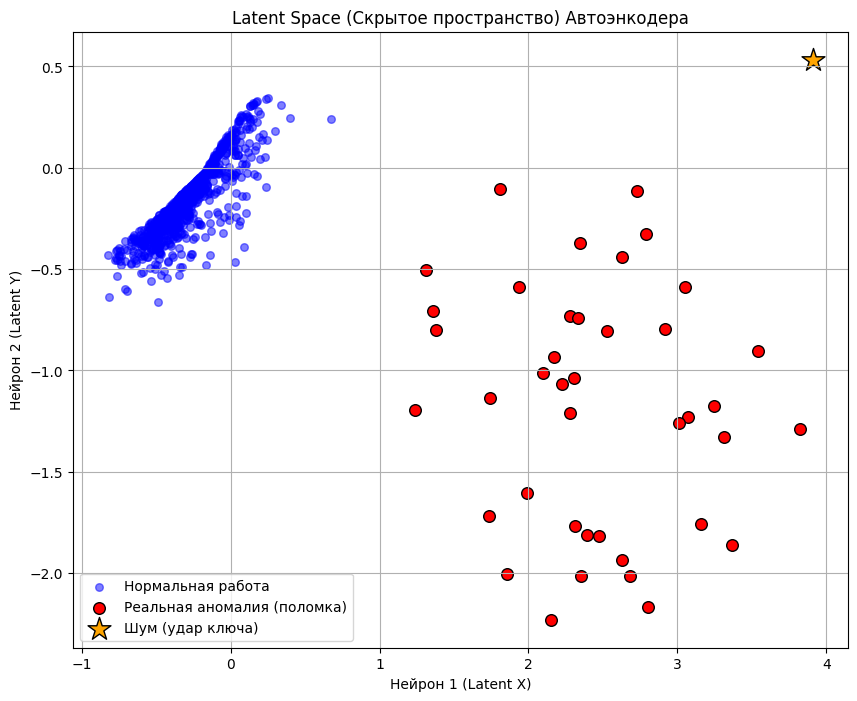

In [9]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE


# 1. Слегка меняем архитектуру (делаем bottleneck = 2)
class VisualAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(2, 16),
            nn.ReLU(),
            nn.Linear(16, 2),  # <-- ТЕПЕРЬ ТУТ 2 НЕЙРОНА (наши X и Y)
        )
        self.decoder = nn.Sequential(nn.Linear(2, 16), nn.ReLU(), nn.Linear(16, 2))

    def forward(self, x):
        return self.decoder(self.encoder(x))


# (Предположим, мы быстро обучили эту model_visual_ae на тех же данных,
# код обучения я опускаю, он идентичен первому примеру)
model_visual_ae = VisualAutoencoder()
# ... тут был бы цикл обучения ...

# 2. ИЗВЛЕКАЕМ EMBEDDINGS (Скрытые представления)
model_visual_ae.eval()
with torch.no_grad():
    # Берем весь наш датасет и прогоняем ТОЛЬКО через энкодер
    embeddings = model_visual_ae.encoder(X_tensor).numpy()

# Теперь embeddings - это матрица размером (1000, 2)

# 3. ВИЗУАЛИЗИРУЕМ
plt.figure(figsize=(10, 8))

# Рисуем все нормальные точки (с 0 по 960 час)
plt.scatter(
    embeddings[:960, 0], embeddings[:960, 1], c="blue", alpha=0.5, label="Нормальная работа", s=30
)

# Рисуем пред-аварийное состояние (с 960 по 1000 час)
plt.scatter(
    embeddings[960:, 0],
    embeddings[960:, 1],
    c="red",
    edgecolors="black",
    label="Реальная аномалия (поломка)",
    s=70,
)

# Отметим наш единичный удар ключом на 200-м часу
plt.scatter(
    embeddings[200, 0],
    embeddings[200, 1],
    c="orange",
    marker="*",
    edgecolors="black",
    label="Шум (удар ключа)",
    s=300,
)

plt.title("Latent Space (Скрытое пространство) Автоэнкодера")
plt.xlabel("Нейрон 1 (Latent X)")
plt.ylabel("Нейрон 2 (Latent Y)")
plt.legend()
plt.grid(True)
plt.show()